# Text Classification Trainer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/text-classifier/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/text-classifier/demo.ipynb)

> "Auto-tag our support tickets" — train a TF-IDF + logistic-regression classifier and route new text by category.

Not every text task needs an LLM. For routing tickets into billing / technical / account, a
**TF-IDF + logistic regression** classifier is faster, cheaper, fully offline, and - crucially -
*interpretable*: you can see the exact words that drive each decision.

**What this notebook covers**
1. Training a text classifier on labeled examples
2. Evaluating on a held-out split (accuracy, confusion)
3. The words that drive each class (interpretability)
4. Tagging brand-new tickets
5. The confusion matrix, visualized


## Step 1 - Train on labeled tickets

30 support tickets across three categories. The pipeline vectorizes text (TF-IDF, uni+bigrams) and
fits a logistic regression - a strong, simple baseline for short-text classification.

In [1]:
from classifier import train_classifier, predict, top_features, sample_data

texts, labels = sample_data()
model = train_classifier(texts, labels)
print(f"Trained on {len(texts)} examples across {model.labels}")
print(f"Held-out accuracy: {model.accuracy:.0%}")


Trained on 30 examples across ['account', 'billing', 'technical']
Held-out accuracy: 100%


## Step 2 - Interpretability: why it tags what it tags

The best thing about logistic regression on TF-IDF: the model *is* a list of weighted words. These
are the terms that most push a ticket toward each class - a sanity check no black box gives you.

In [2]:
for cls, words in top_features(model).items():
    print(f"{cls:<10}: {', '.join(words)}")


account   : workspace, remove, reset, account, add, transfer
billing   : plan, month, invoice, annual, billed, billed cancelled
technical : requests, app, screen, website slow, website, requests failing


## Step 3 - Tag new tickets

The production use: unseen text in, a label + confidence out. Note it generalizes past exact
wording - "invite a coworker" lands on *account* even though the phrasing differs from training.

In [3]:
for t in ["my card got charged twice",
          "the export button throws an error",
          "how do I invite a coworker",
          "reset my two factor auth"]:
    r = predict(model, t)
    print(f"  {r['label']:<10} ({r['confidence']:.0%})  <- \"{t}\"")


  billing    (62%)  <- "my card got charged twice"
  technical  (52%)  <- "the export button throws an error"
  account    (54%)  <- "how do I invite a coworker"
  account    (61%)  <- "reset my two factor auth"


## Step 4 - The confusion matrix

Where the model confuses classes is more useful than a single accuracy number - it shows which
categories bleed into each other and need more training data.

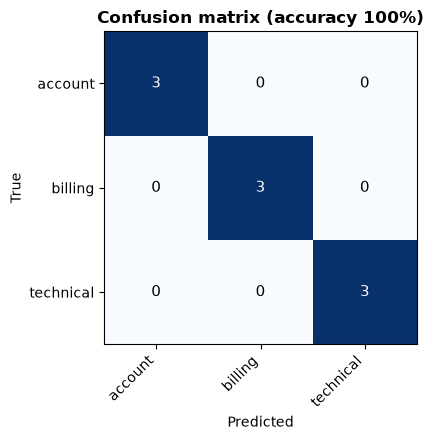

In [4]:
import matplotlib.pyplot as plt

cm = model.confusion
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(model.labels)))
ax.set_xticklabels(model.labels, rotation=45, ha="right")
ax.set_yticks(range(len(model.labels)))
ax.set_yticklabels(model.labels)
for i in range(len(model.labels)):
    for j in range(len(model.labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=11)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (accuracy {model.accuracy:.0%})", fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig("confusion.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Class | Signal words |
|-------|--------------|
| billing | charged, invoice, refund, card |
| technical | error, crash, timeout, export |
| account | password, teammate, role, login |

TF-IDF + logistic regression is the right first tool for text tagging: cheap, offline, interpretable,
and often good enough to route thousands of tickets. Reach for an LLM only when the categories are
subtle or the labeled data is scarce.

**Extend it:** add calibration for trustworthy confidences, an "uncertain → human" threshold, and
periodic retraining as new labeled tickets arrive.

In [5]:
# --- Train on your own labels ---
# texts = ["ticket 1", "ticket 2", ...]
# labels = ["billing", "technical", ...]
# m = train_classifier(texts, labels)
# print(predict(m, "new ticket text"))


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 116,
Month 12: Data Science Cookbook.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`